[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module2/3_Fashion_MNIST_with_fashion_images.ipynb)

🔴
<!-- 🎙 DAVE TALKING POINTS (invisible when rendered - double-click to read):
Video 17 (M2.3) - Fashion MNIST: same recipe, harder problem

- Swap digits for 10 clothing categories, keep the whole recipe: /255, flatten, dense, softmax -> ~88%.
- Point at the drop from 98% to 88%: shirts vs pullovers genuinely look alike at 28x28. Harder data, same code.
- ~450k parameters - have them predict the count before revealing (the video 2 skill, now at scale).
- Message: the recipe transfers. Change the data, keep the skeleton.
-->

# A first look at a neural network with Fashion MNIST
-----------------------
**Dr. Dave Wanik**

This notebook contains the code samples found in Chapter 2, Section 1 of [Deep Learning with Python](https://www.manning.com/books/deep-learning-with-python?a_aid=keras&a_bid=76564dff). Note that the original text features far more content, in particular further explanations and figures: in this notebook, you will only find source code and related comments.

----

We will now take a look at a first concrete example of a neural network, which makes use of the Python library Keras to learn to classify
hand-written digits. Unless you already have experience with Keras or similar libraries, you will not understand everything about this
first example right away. You probably haven't even installed Keras yet. Don't worry, that is perfectly fine. In the next chapter, we will
review each element in our example and explain them in detail. So don't worry if some steps seem arbitrary or look like magic to you!
We've got to start somewhere.

The problem we are trying to solve here is to classify grayscale images of handwritten digits (28 pixels by 28 pixels), into their 10
categories (0 to 9). The dataset we will use is the MNIST dataset, a classic dataset in the machine learning community, which has been
around for almost as long as the field itself and has been very intensively studied. It's a set of 60,000 training images, plus 10,000 test
images, assembled by the National Institute of Standards and Technology (the NIST in MNIST) in the 1980s. You can think of "solving" MNIST
as the "Hello World" of deep learning -- it's what you do to verify that your algorithms are working as expected. As you become a machine
learning practitioner, you will see MNIST come up over and over again, in scientific papers, blog posts, and so on.

The MNIST dataset comes pre-loaded in Keras, in the form of a set of four Numpy arrays:

In [1]:
from keras.datasets import fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

In [2]:
# the labels come as 0-9, but nobody thinks in integers - name them!
# (this order is fixed by the dataset; class 0 is T-shirt/top, class 9 is Ankle boot)
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

for i, n in enumerate(class_names):
    print(i, n)

0 T-shirt/top
1 Trouser
2 Pullover
3 Dress
4 Coat
5 Sandal
6 Shirt
7 Sneaker
8 Bag
9 Ankle boot


`train_images` and `train_labels` form the "training set", the data that the model will learn from. The model will then be tested on the
"test set", `test_images` and `test_labels`. Our images are encoded as Numpy arrays, and the labels are simply an array of digits, ranging
from 0 to 9. There is a one-to-one correspondence between the images and the labels.

Let's have a look at the training data:

In [3]:
train_images.shape

(60000, 28, 28)

In [4]:
len(train_labels)

60000

In [5]:
train_labels

array([9, 0, 0, ..., 3, 0, 5], shape=(60000,), dtype=uint8)

In [6]:
tmp = train_labels
import pandas as pd
tmp = pd.DataFrame(tmp)
tmp[0].value_counts()

0
9    6000
0    6000
3    6000
2    6000
7    6000
5    6000
1    6000
6    6000
4    6000
8    6000
Name: count, dtype: int64

## Look at one image...
Just to get a feel for the data.

In [7]:
# look at one image
import pandas as pd
import numpy as np
import sys

# subset first 'image'
x = train_images[0]
# convert to pandas dataframe for easy viewing...
x = pd.DataFrame(x)
print(x.shape) # 28 rows and 28 columns
# you can confirm
print(train_labels[0])
x # it's the number 9!



(28, 28)
9


,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,1,4,0,0,0,0,1,1,0
4,0,0,0,0,0,0,0,0,0,0,...,54,0,0,0,1,3,4,0,0,3
5,0,0,0,0,0,0,0,0,0,0,...,144,123,23,0,0,0,0,12,10,0
6,0,0,0,0,0,0,0,0,0,0,...,107,156,161,109,64,23,77,130,72,15
7,0,0,0,0,0,0,0,0,0,0,...,216,163,127,121,122,146,141,88,172,66
8,0,0,0,0,0,0,0,0,0,1,...,223,223,215,213,164,127,123,196,229,0
9,0,0,0,0,0,0,0,0,0,0,...,235,227,224,222,224,221,223,245,173,0


## Now actually LOOK at it (imshow!)

That was 784 numbers - exactly what the network sees. You are not a network, so let's use `imshow()`. And with clothing, seeing the data isn't just nice to have: it's how you'll understand every mistake this model makes later on.

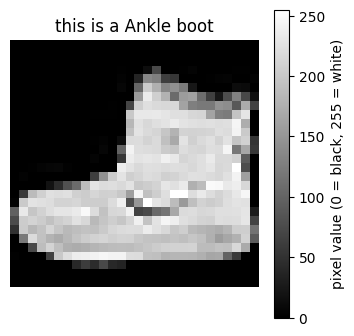

In [8]:
import matplotlib.pyplot as plt

# the same item you just saw as a table of numbers
plt.figure(figsize=(4, 4))
plt.imshow(train_images[0], cmap='gray')
plt.title('this is a %s' % class_names[train_labels[0]])
plt.colorbar(label='pixel value (0 = black, 255 = white)')
plt.axis('off')
plt.show()

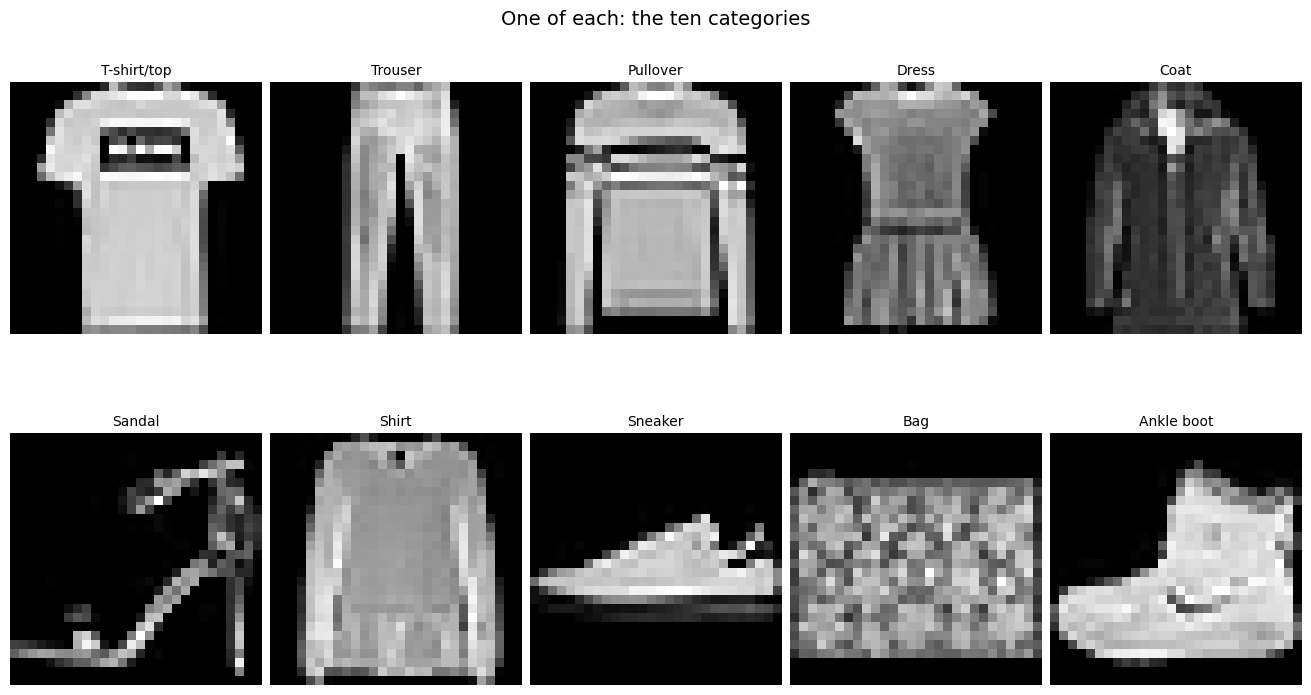

In [9]:
# one of each category - here is the actual task
fig, axes = plt.subplots(2, 5, figsize=(13, 7.3), constrained_layout=True)
for c, ax in zip(range(10), axes.ravel()):
    i = np.where(train_labels == c)[0][0]
    ax.imshow(train_images[i], cmap='gray')
    ax.set_title(class_names[c], fontsize=10)
    ax.axis('off')
fig.suptitle('One of each: the ten categories', fontsize=14)
plt.show()

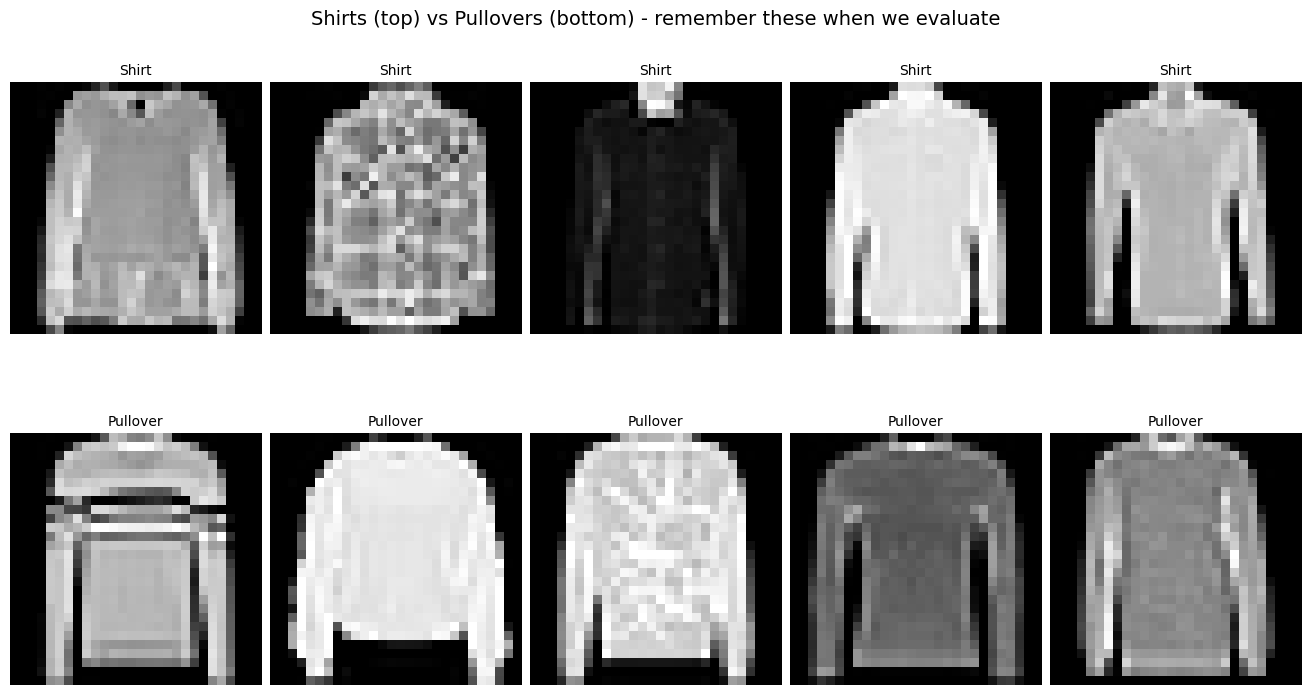

In [10]:
# the hard pair - can YOU tell these apart at 28x28?
fig, axes = plt.subplots(2, 5, figsize=(13, 7.3), constrained_layout=True)
for k, ax in enumerate(axes.ravel()):
    c = 6 if k < 5 else 2                       # 6 = Shirt, 2 = Pullover
    i = np.where(train_labels == c)[0][k % 5]
    ax.imshow(train_images[i], cmap='gray')
    ax.set_title(class_names[c], fontsize=10)
    ax.axis('off')
fig.suptitle('Shirts (top) vs Pullovers (bottom) - remember these when we evaluate', fontsize=14)
plt.show()

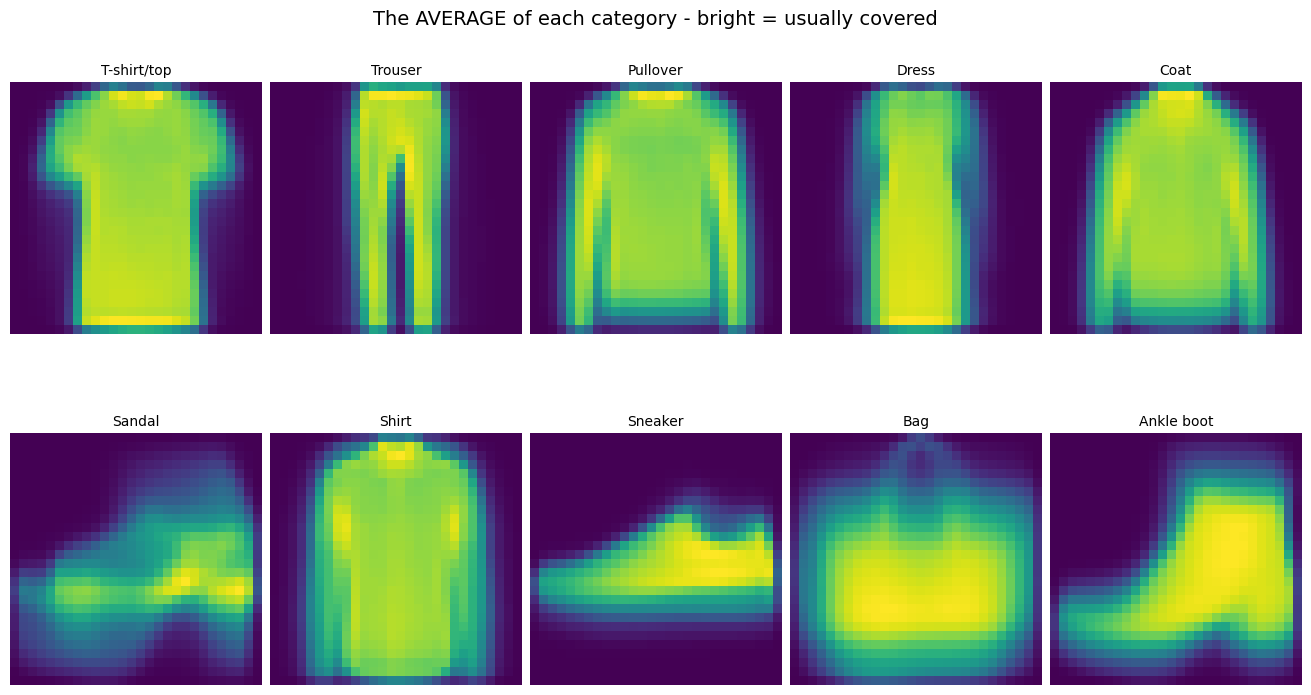

In [11]:
# the average of each category - where does the fabric usually sit?
fig, axes = plt.subplots(2, 5, figsize=(13, 7.3), constrained_layout=True)
for c, ax in zip(range(10), axes.ravel()):
    ax.imshow(train_images[train_labels == c].mean(axis=0), cmap='viridis')
    ax.set_title(class_names[c], fontsize=10)
    ax.axis('off')
fig.suptitle('The AVERAGE of each category - bright = usually covered', fontsize=14)
plt.show()

💡 Look at the average Shirt, the average Pullover, and the average Coat. They are *almost the same picture* - a torso-shaped blob with sleeves. Meanwhile the average Trouser and the average Bag are unmistakable.

You have just predicted your own confusion matrix. The model will be near-perfect on trousers and bags, and it will struggle exactly where those averages overlap. **Good EDA tells you where your model will fail before you ever fit it.**

Let's have a look at the test data:

In [12]:
test_images.shape

(10000, 28, 28)

In [13]:
len(test_labels)

10000

In [14]:
test_labels[0:10] # just a sample of them

array([9, 2, 1, 1, 6, 1, 4, 6, 5, 7], dtype=uint8)

In [15]:
# check out value counts
tmp = test_labels
import pandas as pd
tmp = pd.DataFrame(tmp)
tmp[0].value_counts()

0
9    1000
2    1000
1    1000
6    1000
4    1000
5    1000
7    1000
3    1000
8    1000
0    1000
Name: count, dtype: int64

## So what score do we have to beat?

Same question we ask every single time... what does the laziest possible model get?

Look at those counts: ten clothing categories, exactly **1,000 images each**. Perfectly balanced. So always guessing one category - never even looking at the picture - scores exactly **10%**. That's our floor.

Keep that 10% in your pocket. This problem is harder than the digits, so we won't hit 98% here... but even 88% is a long, long way above what you'd get for free. **Always report your accuracy next to its baseline** - a number by itself doesn't tell anybody whether the model learned anything.

In [16]:
# making a copy for later (logistic regression)
copy_train_labels = train_labels
copy_test_labels = test_labels

Our workflow will be as follow: first we will present our neural network with the training data, `train_images` and `train_labels`. The
network will then learn to associate images and labels. Finally, we will ask the network to produce predictions for `test_images`, and we
will verify if these predictions match the labels from `test_labels`.

Let's build our network -- again, remember that you aren't supposed to understand everything about this example just yet.

In [17]:
from keras import models
from keras import layers
from keras.layers import Dense, Dropout

network = models.Sequential()
network.add(Dense(512, activation='relu', input_shape=(28 * 28,))) # (features, )
network.add(Dropout(0.2))
network.add(Dense(100, activation='relu'))
network.add(Dropout(0.2))
network.add(Dense(10, activation='softmax'))
network.summary()

# note: input shape is the trickiest part IMHO...
# think of it as (number of columns, number of samples)
# number of samples is ALWAYS left blank (you'll set the batch size later on!)

C:\Users\dww05002\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        51,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 454,230 (1.73 MB)

 Trainable params: 454,230 (1.73 MB)

 Non-trainable params: 0 (0.00 B)


The core building block of neural networks is the "layer", a data-processing module which you can conceive as a "filter" for data. Some
data comes in, and comes out in a more useful form. Precisely, layers extract _representations_ out of the data fed into them -- hopefully
representations that are more meaningful for the problem at hand. Most of deep learning really consists of chaining together simple layers
which will implement a form of progressive "data distillation". A deep learning model is like a sieve for data processing, made of a
succession of increasingly refined data filters -- the "layers".

Here our network consists of a sequence of two `Dense` layers, which are densely-connected (also called "fully-connected") neural layers.
The second (and last) layer is a 10-way "softmax" layer, which means it will return an array of 10 probability scores (summing to 1). Each
score will be the probability that the current digit image belongs to one of our 10 digit classes.

To make our network ready for training, we need to pick three more things, as part of "compilation" step:

* A loss function: the is how the network will be able to measure how good a job it is doing on its training data, and thus how it will be
able to steer itself in the right direction.
* An optimizer: this is the mechanism through which the network will update itself based on the data it sees and its loss function.
* Metrics to monitor during training and testing. Here we will only care about accuracy (the fraction of the images that were correctly
classified).

The exact purpose of the loss function and the optimizer will be made clear throughout the next two chapters.

In [18]:
network.compile(optimizer='rmsprop', # you could use rmsprop or Adam - both are good!
                loss='categorical_crossentropy', # many categories - you need to use 'categorical_crossentropy' and NOT 'binary_crossentropy'
                metrics=['accuracy'])


Before training, we will preprocess our data by reshaping it into the shape that the network expects, and scaling it so that all values are in
the `[0, 1]` interval. Previously, our training images for instance were stored in an array of shape `(60000, 28, 28)` of type `uint8` with
values in the `[0, 255]` interval. We transform it into a `float32` array of shape `(60000, 28 * 28)` with values between 0 and 1.

In [19]:
28*28

784

In [20]:
train_images = train_images.reshape((60000, 28 * 28)) # 60K rows, with 784 columns... wow!
train_images = train_images.astype('float32') / 255 # here we are scaling by max pixel value (where white =255, black = 0)

test_images = test_images.reshape((10000, 28 * 28))
test_images = test_images.astype('float32') / 255

In [21]:
# BE CURIOUS!
# see what the model did
x = train_images[0] # instead of a 2D array that is 28*28, it's a single row!
x

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [22]:
# you can see this in the entire dataset too
x = pd.DataFrame(train_images)
print(x.shape)
print(28*28) # see how the shape matches up?
x.head(n=10)

# that first sample is now just the first row

(60000, 784)
784


,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0,0.0
1,0.0,0.0,0.0,0.0,0.000000,0.003922,0.000000,0.0,0.000000,0.000000,...,0.466667,0.447059,0.509804,0.298039,0.000000,0.000000,0.000000,0.00000,0.0,0.0
2,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.086275,...,0.000000,0.000000,0.003922,0.000000,0.000000,0.000000,0.000000,0.00000,0.0,0.0
3,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.129412,0.376471,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0,0.0
4,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0,0.0
5,0.0,0.0,0.0,0.0,0.003922,0.000000,0.000000,0.0,0.000000,0.086275,...,0.000000,0.000000,0.000000,0.000000,0.521569,0.654902,0.286275,0.00000,0.0,0.0
6,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0,0.0
7,0.0,0.0,0.0,0.0,0.000000,0.003922,0.003922,0.0,0.000000,0.000000,...,0.000000,0.000000,0.011765,0.000000,0.321569,0.929412,0.905882,0.27451,0.0,0.0
8,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0,0.0
9,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0,0.0


We also need to categorically encode the labels, a step which we explain in Chapter 3:

In [23]:
from tensorflow.keras.utils import to_categorical

train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

In [24]:
# BE CURIOUS! See what it looks like
x = train_labels[0]
print(x)
# check out the output - the first sample

[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


In [25]:
# check them ALL out!
x = train_labels
x = pd.DataFrame(x)
x

# so the labels are in an ARRAY with one column for each potential outcome.

,0,1,2,3,4,5,6,7,8,9
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
59995,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
59996,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
59997,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
59998,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


We are now ready to train our network, which in Keras is done via a call to the `fit` method of the network:
we "fit" the model to its training data.

In [26]:
# on your own, you are welcome to try including early stopping callbacks
history = network.fit(train_images, train_labels, epochs=30, batch_size=128, validation_split=0.2, shuffle=True)

Epoch 1/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 5:11 832ms/step - accuracy: 0.1406 - loss: 2.3340

 12/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4505 - loss: 1.6063    

 24/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5609 - loss: 1.2889

 37/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6003 - loss: 1.1557

 48/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6302 - loss: 1.0670

 59/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6487 - loss: 1.0071

 69/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6656 - loss: 0.9609

 80/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6763 - loss: 0.9283

 90/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6845 - loss: 0.8991

100/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6934 - loss: 0.8714

111/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7001 - loss: 0.8507

120/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7061 - loss: 0.8325

132/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7115 - loss: 0.8137

142/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7164 - loss: 0.8010

151/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7206 - loss: 0.7897

159/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7228 - loss: 0.7818

167/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7270 - loss: 0.7709

175/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7306 - loss: 0.7608

183/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7335 - loss: 0.7517

191/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7363 - loss: 0.7433

200/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7393 - loss: 0.7332

211/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7428 - loss: 0.7228

220/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7450 - loss: 0.7161

230/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7470 - loss: 0.7095

238/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7483 - loss: 0.7046

247/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7499 - loss: 0.6991

255/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7519 - loss: 0.6940

265/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7546 - loss: 0.6857

275/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7571 - loss: 0.6789

284/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7583 - loss: 0.6744

292/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7601 - loss: 0.6697

301/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7618 - loss: 0.6640

310/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7634 - loss: 0.6595

318/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7654 - loss: 0.6536

327/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7664 - loss: 0.6501

337/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7687 - loss: 0.6442

347/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7706 - loss: 0.6393

357/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7720 - loss: 0.6350

369/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7739 - loss: 0.6303

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7749 - loss: 0.6273 - val_accuracy: 0.8238 - val_loss: 0.4515


Epoch 2/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.8281 - loss: 0.4624

 11/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8224 - loss: 0.4775  

 19/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8376 - loss: 0.4427

 29/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8359 - loss: 0.4427

 37/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8338 - loss: 0.4499

 46/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8363 - loss: 0.4474

 56/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8369 - loss: 0.4497

 66/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8349 - loss: 0.4548

 76/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8352 - loss: 0.4526

 87/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8340 - loss: 0.4558

 97/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8352 - loss: 0.4526

107/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8362 - loss: 0.4525

117/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8355 - loss: 0.4520

127/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8349 - loss: 0.4521

136/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8362 - loss: 0.4475

145/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8367 - loss: 0.4472

154/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8374 - loss: 0.4476

163/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8373 - loss: 0.4485

173/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8373 - loss: 0.4458

182/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8383 - loss: 0.4450

194/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8380 - loss: 0.4454

204/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8388 - loss: 0.4436

216/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8385 - loss: 0.4438

227/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8384 - loss: 0.4437

237/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8382 - loss: 0.4438

247/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8387 - loss: 0.4424

260/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8383 - loss: 0.4425

271/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8391 - loss: 0.4407

284/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8399 - loss: 0.4394

294/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8401 - loss: 0.4395

304/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8397 - loss: 0.4394

313/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8399 - loss: 0.4391

322/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8410 - loss: 0.4369

331/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8412 - loss: 0.4360

340/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8411 - loss: 0.4356

349/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8412 - loss: 0.4356

360/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8413 - loss: 0.4354

368/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8418 - loss: 0.4339

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8418 - loss: 0.4339 - val_accuracy: 0.8500 - val_loss: 0.3903


Epoch 3/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - accuracy: 0.8906 - loss: 0.3080

 13/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8492 - loss: 0.4067  

 22/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8562 - loss: 0.3911

 33/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8627 - loss: 0.3713

 43/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8612 - loss: 0.3823

 55/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8621 - loss: 0.3822

 65/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8625 - loss: 0.3801

 76/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8627 - loss: 0.3828

 88/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8587 - loss: 0.3892

102/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8585 - loss: 0.3904

115/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8582 - loss: 0.3915

126/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8580 - loss: 0.3926

137/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8574 - loss: 0.3955

148/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8562 - loss: 0.3950

160/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8548 - loss: 0.3979

171/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8552 - loss: 0.3966

185/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8560 - loss: 0.3946

197/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8561 - loss: 0.3942

207/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8556 - loss: 0.3954

217/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8564 - loss: 0.3948

226/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8562 - loss: 0.3960

235/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8563 - loss: 0.3957

245/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8563 - loss: 0.3944

255/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8566 - loss: 0.3947

264/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8570 - loss: 0.3940

274/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8565 - loss: 0.3941

284/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8568 - loss: 0.3935

293/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8573 - loss: 0.3920

301/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8572 - loss: 0.3931

309/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8573 - loss: 0.3925

320/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8576 - loss: 0.3907

329/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8580 - loss: 0.3895

339/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8586 - loss: 0.3881

348/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8585 - loss: 0.3874

358/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8590 - loss: 0.3873

368/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8592 - loss: 0.3857

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8586 - loss: 0.3870 - val_accuracy: 0.8572 - val_loss: 0.3835


Epoch 4/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - accuracy: 0.8828 - loss: 0.2972

 11/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8672 - loss: 0.3690  

 24/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8734 - loss: 0.3428

 34/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8750 - loss: 0.3383

 44/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8704 - loss: 0.3453

 54/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8728 - loss: 0.3383

 64/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8724 - loss: 0.3451

 74/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8737 - loss: 0.3421

 83/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8726 - loss: 0.3481

 93/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8721 - loss: 0.3492

104/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8727 - loss: 0.3476

114/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8734 - loss: 0.3464

123/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8730 - loss: 0.3485

133/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8715 - loss: 0.3544

142/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8705 - loss: 0.3578

150/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8705 - loss: 0.3590

158/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8703 - loss: 0.3606

166/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8710 - loss: 0.3600

174/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8712 - loss: 0.3587

182/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8708 - loss: 0.3588

190/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8707 - loss: 0.3585

198/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8698 - loss: 0.3612

208/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8696 - loss: 0.3614

218/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8690 - loss: 0.3619

227/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8681 - loss: 0.3628

236/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8679 - loss: 0.3622

245/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8681 - loss: 0.3620

255/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8687 - loss: 0.3606

265/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8692 - loss: 0.3591

275/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8693 - loss: 0.3580

285/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8692 - loss: 0.3580

295/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8689 - loss: 0.3592

305/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8688 - loss: 0.3598

316/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8688 - loss: 0.3597

325/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8686 - loss: 0.3590

335/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8692 - loss: 0.3578

345/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8689 - loss: 0.3586

356/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8687 - loss: 0.3581

367/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8685 - loss: 0.3582

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8686 - loss: 0.3583 - val_accuracy: 0.8773 - val_loss: 0.3411


Epoch 5/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.8750 - loss: 0.3274

 12/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8815 - loss: 0.3317  

 22/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8839 - loss: 0.3188

 33/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8764 - loss: 0.3358

 43/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8783 - loss: 0.3332

 54/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8783 - loss: 0.3309

 64/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8776 - loss: 0.3330

 74/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8771 - loss: 0.3367

 82/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8790 - loss: 0.3336

 91/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8789 - loss: 0.3329

 99/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8778 - loss: 0.3356

108/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8774 - loss: 0.3383

118/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8763 - loss: 0.3402

127/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8763 - loss: 0.3398

137/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8756 - loss: 0.3408

149/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8766 - loss: 0.3402

158/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8764 - loss: 0.3388

169/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8765 - loss: 0.3403

180/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8760 - loss: 0.3397

190/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8754 - loss: 0.3404

200/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8754 - loss: 0.3398

211/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8753 - loss: 0.3400

220/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8750 - loss: 0.3400

231/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8754 - loss: 0.3394

241/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8757 - loss: 0.3388

251/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8766 - loss: 0.3371

262/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8768 - loss: 0.3370

273/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8768 - loss: 0.3371

285/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8759 - loss: 0.3379

295/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8760 - loss: 0.3386

309/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8761 - loss: 0.3394

320/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8758 - loss: 0.3412

330/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8759 - loss: 0.3408

342/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8758 - loss: 0.3402

355/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8763 - loss: 0.3391

366/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8756 - loss: 0.3397

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8754 - loss: 0.3396 - val_accuracy: 0.8758 - val_loss: 0.3403


Epoch 6/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 1:56 312ms/step - accuracy: 0.8750 - loss: 0.3781

 13/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8768 - loss: 0.3305    

 25/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8813 - loss: 0.3301

 39/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8824 - loss: 0.3265

 49/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8820 - loss: 0.3187

 58/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8777 - loss: 0.3277

 67/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8797 - loss: 0.3202

 75/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8779 - loss: 0.3233

 85/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8779 - loss: 0.3259

 98/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8769 - loss: 0.3274

111/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8763 - loss: 0.3277

122/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8766 - loss: 0.3281

133/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8765 - loss: 0.3288

145/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8763 - loss: 0.3292

157/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8767 - loss: 0.3281

171/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8778 - loss: 0.3283

182/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8778 - loss: 0.3285

192/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8787 - loss: 0.3272

203/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8794 - loss: 0.3258

214/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8792 - loss: 0.3260

223/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8792 - loss: 0.3263

233/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8796 - loss: 0.3266

242/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8794 - loss: 0.3268

253/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8792 - loss: 0.3289

263/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8796 - loss: 0.3284

271/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8797 - loss: 0.3282

280/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8796 - loss: 0.3280

288/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8796 - loss: 0.3270

297/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8802 - loss: 0.3263

307/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8800 - loss: 0.3264

316/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8804 - loss: 0.3258

326/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8804 - loss: 0.3260

336/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8803 - loss: 0.3262

347/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8804 - loss: 0.3253

357/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8801 - loss: 0.3251

368/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8800 - loss: 0.3254

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8803 - loss: 0.3243 - val_accuracy: 0.8704 - val_loss: 0.3705


Epoch 7/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - accuracy: 0.8594 - loss: 0.3456

 11/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8928 - loss: 0.3063  

 22/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8899 - loss: 0.3052

 34/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8883 - loss: 0.3053

 45/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8901 - loss: 0.3008

 57/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8910 - loss: 0.3007

 70/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8890 - loss: 0.3057

 81/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8874 - loss: 0.3064

 94/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8871 - loss: 0.3095

105/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8856 - loss: 0.3090

115/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8856 - loss: 0.3089

127/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8848 - loss: 0.3110

137/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8849 - loss: 0.3104

146/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8862 - loss: 0.3090

156/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8860 - loss: 0.3100

167/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8859 - loss: 0.3085

175/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8851 - loss: 0.3086

184/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8850 - loss: 0.3092

192/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8853 - loss: 0.3097

201/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8856 - loss: 0.3106

209/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8860 - loss: 0.3103

218/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8858 - loss: 0.3100

228/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8853 - loss: 0.3099

237/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8847 - loss: 0.3109

246/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8848 - loss: 0.3110

258/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8844 - loss: 0.3123

270/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8845 - loss: 0.3122

280/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8846 - loss: 0.3122

290/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8848 - loss: 0.3118

301/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8839 - loss: 0.3135

311/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8837 - loss: 0.3142

321/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8841 - loss: 0.3141

332/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8841 - loss: 0.3149

341/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8840 - loss: 0.3152

354/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8834 - loss: 0.3169

365/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8838 - loss: 0.3159

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8836 - loss: 0.3175 - val_accuracy: 0.8789 - val_loss: 0.3312


Epoch 8/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 15s 41ms/step - accuracy: 0.8906 - loss: 0.2972

 12/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8952 - loss: 0.2923  

 24/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8854 - loss: 0.3104

 36/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8895 - loss: 0.3000

 46/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8886 - loss: 0.2979

 57/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8893 - loss: 0.2973

 69/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8873 - loss: 0.3018

 79/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8873 - loss: 0.3032

 89/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8854 - loss: 0.3060

 98/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8868 - loss: 0.3023

106/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8863 - loss: 0.3015

115/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8858 - loss: 0.3045

125/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8846 - loss: 0.3052

134/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8831 - loss: 0.3095

145/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8833 - loss: 0.3087

155/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8840 - loss: 0.3078

166/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8844 - loss: 0.3065

176/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8848 - loss: 0.3058

186/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8855 - loss: 0.3051

196/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8852 - loss: 0.3054

206/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8854 - loss: 0.3052

216/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8859 - loss: 0.3047

226/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8859 - loss: 0.3037

236/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8862 - loss: 0.3033

246/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8863 - loss: 0.3031

257/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8863 - loss: 0.3044

267/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8859 - loss: 0.3061

280/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8857 - loss: 0.3073

290/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8862 - loss: 0.3074

300/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8859 - loss: 0.3078

310/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8860 - loss: 0.3079

320/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8862 - loss: 0.3076

331/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8860 - loss: 0.3080

342/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8866 - loss: 0.3069

353/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8866 - loss: 0.3082

366/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8872 - loss: 0.3067

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8869 - loss: 0.3074 - val_accuracy: 0.8839 - val_loss: 0.3391


Epoch 9/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 15s 40ms/step - accuracy: 0.9141 - loss: 0.2194

 10/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9102 - loss: 0.2827  

 20/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9027 - loss: 0.2768

 32/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8994 - loss: 0.2825

 43/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8964 - loss: 0.2849

 52/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8936 - loss: 0.2899

 63/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8917 - loss: 0.2925

 74/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8925 - loss: 0.2909

 83/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8912 - loss: 0.2934

 93/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8921 - loss: 0.2901

104/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8930 - loss: 0.2892

114/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8933 - loss: 0.2879

124/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8927 - loss: 0.2893

134/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8927 - loss: 0.2897

145/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8928 - loss: 0.2911

158/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8923 - loss: 0.2921

169/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8922 - loss: 0.2917

181/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8919 - loss: 0.2952

192/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8915 - loss: 0.2958

204/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8923 - loss: 0.2945

216/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8919 - loss: 0.2953

228/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8925 - loss: 0.2944

240/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8919 - loss: 0.2965

251/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8912 - loss: 0.2982

262/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8902 - loss: 0.2997

273/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8907 - loss: 0.2980

285/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8911 - loss: 0.2967

295/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8912 - loss: 0.2963

304/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8908 - loss: 0.2963

314/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8910 - loss: 0.2958

326/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8910 - loss: 0.2956

336/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8909 - loss: 0.2960

345/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8910 - loss: 0.2951

354/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8913 - loss: 0.2943

362/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8915 - loss: 0.2943

371/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8915 - loss: 0.2949

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8915 - loss: 0.2948 - val_accuracy: 0.8792 - val_loss: 0.3360


Epoch 10/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.9141 - loss: 0.2522

 10/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8984 - loss: 0.2639 

 21/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8981 - loss: 0.2659

 31/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8989 - loss: 0.2680

 41/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8944 - loss: 0.2796

 51/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8968 - loss: 0.2777

 60/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8978 - loss: 0.2755

 73/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8982 - loss: 0.2764

 83/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8984 - loss: 0.2777

 93/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8976 - loss: 0.2786

103/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8962 - loss: 0.2844

114/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8970 - loss: 0.2838

125/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8969 - loss: 0.2820

135/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8967 - loss: 0.2820

146/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8957 - loss: 0.2852

157/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8955 - loss: 0.2850

168/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8951 - loss: 0.2852

179/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8945 - loss: 0.2892

189/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8943 - loss: 0.2894

198/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8941 - loss: 0.2896

207/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8947 - loss: 0.2877

215/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8952 - loss: 0.2864

225/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8946 - loss: 0.2880

234/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8948 - loss: 0.2870

244/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8951 - loss: 0.2869

253/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8949 - loss: 0.2885

264/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8949 - loss: 0.2891

273/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8945 - loss: 0.2898

281/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8943 - loss: 0.2899

291/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8945 - loss: 0.2892

300/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8942 - loss: 0.2898

311/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8943 - loss: 0.2900

322/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8943 - loss: 0.2897

329/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8945 - loss: 0.2891

339/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8952 - loss: 0.2876

348/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8949 - loss: 0.2882

359/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8951 - loss: 0.2884

368/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8951 - loss: 0.2883

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8950 - loss: 0.2886 - val_accuracy: 0.8811 - val_loss: 0.3407


Epoch 11/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.8906 - loss: 0.2101

 11/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8913 - loss: 0.2695  

 24/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8896 - loss: 0.2874

 35/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8920 - loss: 0.2902

 46/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8933 - loss: 0.2890

 58/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8926 - loss: 0.2916

 68/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8929 - loss: 0.2895

 79/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8941 - loss: 0.2860

 89/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8942 - loss: 0.2868

100/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8948 - loss: 0.2862

111/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8953 - loss: 0.2854

121/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8961 - loss: 0.2842

130/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8964 - loss: 0.2827

139/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8955 - loss: 0.2830

148/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8962 - loss: 0.2827

157/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8958 - loss: 0.2822

167/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8959 - loss: 0.2812

175/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8959 - loss: 0.2815

184/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8954 - loss: 0.2821

192/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8955 - loss: 0.2831

200/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8953 - loss: 0.2832

210/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8947 - loss: 0.2853

220/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8946 - loss: 0.2850

230/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8945 - loss: 0.2855

241/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8949 - loss: 0.2856

251/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8946 - loss: 0.2865

260/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8944 - loss: 0.2868

271/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8943 - loss: 0.2867

280/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8943 - loss: 0.2863

290/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8949 - loss: 0.2856

300/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8946 - loss: 0.2855

311/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8944 - loss: 0.2856

321/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8943 - loss: 0.2853

330/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8942 - loss: 0.2859

342/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8943 - loss: 0.2855

352/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8940 - loss: 0.2856

362/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8939 - loss: 0.2854

372/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8940 - loss: 0.2852

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8939 - loss: 0.2855 - val_accuracy: 0.8837 - val_loss: 0.3372


Epoch 12/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 13s 37ms/step - accuracy: 0.9141 - loss: 0.2179

 14/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8890 - loss: 0.2834  

 25/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8938 - loss: 0.2845

 35/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8908 - loss: 0.2847

 45/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8939 - loss: 0.2810

 52/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8935 - loss: 0.2799

 61/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8936 - loss: 0.2824

 70/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8965 - loss: 0.2795

 80/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8975 - loss: 0.2793

 89/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8961 - loss: 0.2821

 98/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8964 - loss: 0.2787

106/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8970 - loss: 0.2765

115/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8971 - loss: 0.2788

124/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8977 - loss: 0.2781

135/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8981 - loss: 0.2790

145/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8976 - loss: 0.2808

155/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8983 - loss: 0.2781

166/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8981 - loss: 0.2789

176/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8975 - loss: 0.2799

186/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8976 - loss: 0.2796

196/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8978 - loss: 0.2787

206/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8979 - loss: 0.2783

216/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8975 - loss: 0.2783

226/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8977 - loss: 0.2773

237/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8972 - loss: 0.2781

247/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8976 - loss: 0.2773

259/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8974 - loss: 0.2784

269/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8972 - loss: 0.2794

279/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8972 - loss: 0.2790

290/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8969 - loss: 0.2785

302/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8974 - loss: 0.2796

314/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8976 - loss: 0.2788

327/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8975 - loss: 0.2781

337/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8979 - loss: 0.2777

347/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8977 - loss: 0.2787

358/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8979 - loss: 0.2786

368/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8984 - loss: 0.2784

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8982 - loss: 0.2785 - val_accuracy: 0.8869 - val_loss: 0.3405


Epoch 13/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 17s 45ms/step - accuracy: 0.8984 - loss: 0.2648

 11/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8984 - loss: 0.2677  

 23/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9069 - loss: 0.2449

 34/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9019 - loss: 0.2580

 44/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9006 - loss: 0.2615

 54/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8993 - loss: 0.2645

 66/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8976 - loss: 0.2694

 75/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9001 - loss: 0.2652

 85/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8984 - loss: 0.2668

 98/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8998 - loss: 0.2649

110/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8987 - loss: 0.2671

120/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8993 - loss: 0.2652

129/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8993 - loss: 0.2666

139/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9000 - loss: 0.2672

152/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8999 - loss: 0.2689

163/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9001 - loss: 0.2704

173/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9010 - loss: 0.2671

186/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9001 - loss: 0.2684

197/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8992 - loss: 0.2715

208/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8985 - loss: 0.2737

222/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8991 - loss: 0.2723

233/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8981 - loss: 0.2742

245/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8979 - loss: 0.2750

256/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8977 - loss: 0.2748

268/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8979 - loss: 0.2743

279/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8978 - loss: 0.2752

287/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8975 - loss: 0.2761

297/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8977 - loss: 0.2756

307/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8977 - loss: 0.2751

317/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8978 - loss: 0.2745

326/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8975 - loss: 0.2752

335/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8975 - loss: 0.2752

344/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8973 - loss: 0.2760

352/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8976 - loss: 0.2752

361/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8977 - loss: 0.2753

372/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8978 - loss: 0.2750

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8979 - loss: 0.2749 - val_accuracy: 0.8818 - val_loss: 0.3519


Epoch 14/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.9062 - loss: 0.2351

 10/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9148 - loss: 0.2368  

 21/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9074 - loss: 0.2547

 31/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9065 - loss: 0.2596

 41/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9045 - loss: 0.2647

 52/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9085 - loss: 0.2600

 64/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9064 - loss: 0.2612

 75/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9066 - loss: 0.2594

 85/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9053 - loss: 0.2606

 97/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9049 - loss: 0.2617

107/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9049 - loss: 0.2631

122/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9047 - loss: 0.2640

132/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9036 - loss: 0.2651

144/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9038 - loss: 0.2643

155/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9026 - loss: 0.2667

166/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9030 - loss: 0.2668

176/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9032 - loss: 0.2658

185/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9035 - loss: 0.2649

195/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9038 - loss: 0.2629

206/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9032 - loss: 0.2643

216/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9031 - loss: 0.2648

226/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9028 - loss: 0.2658

235/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9017 - loss: 0.2682

245/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9018 - loss: 0.2673

253/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9016 - loss: 0.2671

262/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9014 - loss: 0.2686

272/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9020 - loss: 0.2683

281/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9023 - loss: 0.2674

291/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9023 - loss: 0.2679

300/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9024 - loss: 0.2674

311/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9019 - loss: 0.2685

323/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9019 - loss: 0.2680

333/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9018 - loss: 0.2677

342/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9021 - loss: 0.2666

352/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9020 - loss: 0.2673

361/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9017 - loss: 0.2675

372/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9018 - loss: 0.2677

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9016 - loss: 0.2687 - val_accuracy: 0.8887 - val_loss: 0.3169


Epoch 15/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.9453 - loss: 0.2511

 12/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9017 - loss: 0.2583  

 23/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9032 - loss: 0.2521

 34/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9026 - loss: 0.2645

 45/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9017 - loss: 0.2622

 59/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9040 - loss: 0.2598

 70/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9042 - loss: 0.2648

 81/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9024 - loss: 0.2671

 90/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9031 - loss: 0.2642

100/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9034 - loss: 0.2606

109/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9028 - loss: 0.2608

121/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9031 - loss: 0.2592

130/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9029 - loss: 0.2597

139/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9027 - loss: 0.2611

149/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9033 - loss: 0.2608

158/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9023 - loss: 0.2626

166/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9028 - loss: 0.2613

175/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9019 - loss: 0.2625

184/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9020 - loss: 0.2621

193/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9023 - loss: 0.2616

203/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9031 - loss: 0.2608

212/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9026 - loss: 0.2616

222/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9027 - loss: 0.2611

233/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9026 - loss: 0.2607

243/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9020 - loss: 0.2620

253/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9027 - loss: 0.2615

262/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9027 - loss: 0.2610

272/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9029 - loss: 0.2619

281/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9031 - loss: 0.2618

291/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9031 - loss: 0.2617

303/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9026 - loss: 0.2623

313/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9027 - loss: 0.2620

323/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9024 - loss: 0.2623

336/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9018 - loss: 0.2639

347/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9019 - loss: 0.2629

360/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9022 - loss: 0.2630

372/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9025 - loss: 0.2624

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9024 - loss: 0.2625 - val_accuracy: 0.8928 - val_loss: 0.3297


Epoch 16/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - accuracy: 0.9141 - loss: 0.2868

 11/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9034 - loss: 0.2703  

 24/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9007 - loss: 0.2803

 34/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9030 - loss: 0.2734

 43/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9017 - loss: 0.2782

 52/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9023 - loss: 0.2732

 60/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9029 - loss: 0.2700

 69/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9032 - loss: 0.2699

 79/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9044 - loss: 0.2711

 89/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9032 - loss: 0.2699

 99/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9040 - loss: 0.2676

109/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9033 - loss: 0.2669

120/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9031 - loss: 0.2656

131/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9025 - loss: 0.2663

141/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9033 - loss: 0.2638

153/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9032 - loss: 0.2652

165/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9020 - loss: 0.2667

174/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9015 - loss: 0.2674

183/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9014 - loss: 0.2671

192/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9014 - loss: 0.2678

201/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9010 - loss: 0.2673

210/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9008 - loss: 0.2683

223/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9009 - loss: 0.2683

233/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9015 - loss: 0.2667

243/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9013 - loss: 0.2669

256/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9013 - loss: 0.2662

267/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9013 - loss: 0.2663

278/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9020 - loss: 0.2653

288/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9021 - loss: 0.2649

299/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9023 - loss: 0.2644

310/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9027 - loss: 0.2635

321/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9031 - loss: 0.2629

332/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9035 - loss: 0.2624

341/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9035 - loss: 0.2620

352/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9033 - loss: 0.2624

362/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9034 - loss: 0.2622

372/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9036 - loss: 0.2617

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9035 - loss: 0.2617 - val_accuracy: 0.8944 - val_loss: 0.3292


Epoch 17/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - accuracy: 0.8906 - loss: 0.2718

 11/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9070 - loss: 0.2365  

 22/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9109 - loss: 0.2365

 33/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9079 - loss: 0.2456

 44/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9102 - loss: 0.2482

 54/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9090 - loss: 0.2516

 64/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9105 - loss: 0.2516

 77/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9105 - loss: 0.2494

 87/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9090 - loss: 0.2524

 98/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9090 - loss: 0.2535

107/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9090 - loss: 0.2518

116/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9091 - loss: 0.2513

126/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9084 - loss: 0.2527

136/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9072 - loss: 0.2540

147/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9070 - loss: 0.2547

160/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9070 - loss: 0.2543

171/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9067 - loss: 0.2547

181/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9064 - loss: 0.2560

194/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9062 - loss: 0.2563

206/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9060 - loss: 0.2567

217/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9061 - loss: 0.2562

228/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9058 - loss: 0.2567

239/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9061 - loss: 0.2565

251/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9060 - loss: 0.2560

261/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9058 - loss: 0.2564

270/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9060 - loss: 0.2568

280/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9060 - loss: 0.2566

289/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9055 - loss: 0.2579

299/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9053 - loss: 0.2581

308/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9054 - loss: 0.2576

316/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9053 - loss: 0.2582

325/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9051 - loss: 0.2579

334/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9051 - loss: 0.2573

342/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9052 - loss: 0.2573

352/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9054 - loss: 0.2569

361/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9056 - loss: 0.2566

369/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9054 - loss: 0.2568

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9053 - loss: 0.2571 - val_accuracy: 0.8898 - val_loss: 0.3271


Epoch 18/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - accuracy: 0.9141 - loss: 0.2513

 10/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9172 - loss: 0.2243  

 21/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9133 - loss: 0.2277

 31/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9110 - loss: 0.2437

 41/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9135 - loss: 0.2448

 52/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9124 - loss: 0.2435

 64/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9102 - loss: 0.2510

 74/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9110 - loss: 0.2479

 85/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9097 - loss: 0.2502

 94/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9104 - loss: 0.2474

105/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9109 - loss: 0.2477

115/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9100 - loss: 0.2512

122/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9083 - loss: 0.2549

128/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9083 - loss: 0.2553

133/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9071 - loss: 0.2574

138/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9069 - loss: 0.2565

143/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9072 - loss: 0.2557

149/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9077 - loss: 0.2556

154/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9076 - loss: 0.2545

159/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9069 - loss: 0.2570

164/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9067 - loss: 0.2566

170/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9070 - loss: 0.2549

175/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9069 - loss: 0.2544

180/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9067 - loss: 0.2545

186/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9064 - loss: 0.2543

191/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9069 - loss: 0.2530

196/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9067 - loss: 0.2534

199/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9064 - loss: 0.2542

205/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9064 - loss: 0.2539

211/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9061 - loss: 0.2540

216/375 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9061 - loss: 0.2537

222/375 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9063 - loss: 0.2536

228/375 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9067 - loss: 0.2533

234/375 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9067 - loss: 0.2532

239/375 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9068 - loss: 0.2536

245/375 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9068 - loss: 0.2539

251/375 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9067 - loss: 0.2533

257/375 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9069 - loss: 0.2539

262/375 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9072 - loss: 0.2529

267/375 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9074 - loss: 0.2521

272/375 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9072 - loss: 0.2527

278/375 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9069 - loss: 0.2531

283/375 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9075 - loss: 0.2517

288/375 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9073 - loss: 0.2523

293/375 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9074 - loss: 0.2519

299/375 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9075 - loss: 0.2522

304/375 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9075 - loss: 0.2522

310/375 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9073 - loss: 0.2529

316/375 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9071 - loss: 0.2531

321/375 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9070 - loss: 0.2535

326/375 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9070 - loss: 0.2535

331/375 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9069 - loss: 0.2539

336/375 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9072 - loss: 0.2536

343/375 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9074 - loss: 0.2533

349/375 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9075 - loss: 0.2532

355/375 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9075 - loss: 0.2534

361/375 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9073 - loss: 0.2534

367/375 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9073 - loss: 0.2531

374/375 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9072 - loss: 0.2529

375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9071 - loss: 0.2530 - val_accuracy: 0.8866 - val_loss: 0.3387


Epoch 19/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 22s 60ms/step - accuracy: 0.8750 - loss: 0.3327

  6/375 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9049 - loss: 0.2478 

 12/375 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9102 - loss: 0.2482

 18/375 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9097 - loss: 0.2380

 24/375 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9092 - loss: 0.2377

 29/375 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9124 - loss: 0.2330

 34/375 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9115 - loss: 0.2345

 39/375 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9107 - loss: 0.2356

 44/375 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9087 - loss: 0.2387

 50/375 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9083 - loss: 0.2399

 57/375 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9082 - loss: 0.2440

 63/375 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9075 - loss: 0.2453

 68/375 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9080 - loss: 0.2446

 74/375 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9072 - loss: 0.2454

 80/375 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9077 - loss: 0.2468

 87/375 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9085 - loss: 0.2464

 93/375 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9078 - loss: 0.2457

 99/375 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9076 - loss: 0.2497

105/375 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9083 - loss: 0.2490

110/375 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9087 - loss: 0.2503

116/375 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9089 - loss: 0.2510

122/375 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9090 - loss: 0.2518

128/375 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9092 - loss: 0.2507

133/375 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9091 - loss: 0.2507

139/375 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9086 - loss: 0.2524

145/375 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9088 - loss: 0.2511

151/375 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9084 - loss: 0.2510

156/375 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9082 - loss: 0.2503

161/375 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9079 - loss: 0.2515

167/375 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9091 - loss: 0.2492

173/375 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9091 - loss: 0.2488

179/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9091 - loss: 0.2490

184/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9085 - loss: 0.2499

190/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9076 - loss: 0.2510

195/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9073 - loss: 0.2505

200/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9070 - loss: 0.2512

205/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9068 - loss: 0.2512

210/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9068 - loss: 0.2522

215/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9066 - loss: 0.2526

220/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9062 - loss: 0.2529

226/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9064 - loss: 0.2523

233/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9067 - loss: 0.2507

239/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9071 - loss: 0.2502

246/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9072 - loss: 0.2497

251/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9076 - loss: 0.2495

257/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9078 - loss: 0.2490

263/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9082 - loss: 0.2485

268/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9078 - loss: 0.2495

275/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9074 - loss: 0.2501

281/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9074 - loss: 0.2502

287/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9074 - loss: 0.2500

293/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9076 - loss: 0.2496

298/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9080 - loss: 0.2485

303/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9080 - loss: 0.2485

309/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9074 - loss: 0.2504

315/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9077 - loss: 0.2503

321/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9077 - loss: 0.2500

327/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9081 - loss: 0.2492

332/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9081 - loss: 0.2492

337/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9081 - loss: 0.2495

342/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9080 - loss: 0.2498

347/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9079 - loss: 0.2499

352/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9079 - loss: 0.2499

357/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9083 - loss: 0.2497

362/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9084 - loss: 0.2494

368/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9086 - loss: 0.2491

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9084 - loss: 0.2491

375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9084 - loss: 0.2491 - val_accuracy: 0.8924 - val_loss: 0.3462


Epoch 20/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 30s 80ms/step - accuracy: 0.9062 - loss: 0.2023

  6/375 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8984 - loss: 0.2808 

 11/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9148 - loss: 0.2391

 17/375 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9099 - loss: 0.2478

 21/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9092 - loss: 0.2411

 26/375 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9069 - loss: 0.2439

 31/375 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9068 - loss: 0.2411

 37/375 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9054 - loss: 0.2421

 42/375 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9064 - loss: 0.2454

 47/375 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9071 - loss: 0.2450

 52/375 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9073 - loss: 0.2426

 56/375 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9086 - loss: 0.2407

 62/375 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9073 - loss: 0.2424

 68/375 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9067 - loss: 0.2436

 73/375 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9077 - loss: 0.2404

 79/375 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9077 - loss: 0.2404

 86/375 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9076 - loss: 0.2408

 92/375 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9068 - loss: 0.2418

 97/375 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9069 - loss: 0.2425

103/375 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9057 - loss: 0.2446

109/375 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9047 - loss: 0.2472

114/375 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9045 - loss: 0.2489

120/375 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9046 - loss: 0.2468

126/375 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9047 - loss: 0.2455

131/375 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9043 - loss: 0.2470

137/375 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9046 - loss: 0.2467

143/375 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9047 - loss: 0.2458

148/375 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9051 - loss: 0.2449

154/375 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9060 - loss: 0.2435

160/375 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9061 - loss: 0.2438

165/375 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9065 - loss: 0.2429

170/375 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9069 - loss: 0.2422

176/375 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9071 - loss: 0.2414

182/375 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9072 - loss: 0.2407

187/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9075 - loss: 0.2400

192/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9075 - loss: 0.2408

197/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9073 - loss: 0.2407

202/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9079 - loss: 0.2401

207/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9076 - loss: 0.2414

213/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9078 - loss: 0.2413

219/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9083 - loss: 0.2401

226/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9081 - loss: 0.2404

232/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9086 - loss: 0.2394

237/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9083 - loss: 0.2406

243/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9081 - loss: 0.2407

250/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9079 - loss: 0.2414

256/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9082 - loss: 0.2409

263/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9082 - loss: 0.2416

268/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9085 - loss: 0.2412

274/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9084 - loss: 0.2419

280/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9086 - loss: 0.2422

285/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9088 - loss: 0.2421

291/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9090 - loss: 0.2413

297/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9092 - loss: 0.2414

303/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9091 - loss: 0.2415

308/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9088 - loss: 0.2427

314/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9088 - loss: 0.2423

320/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9087 - loss: 0.2428

324/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9088 - loss: 0.2421

330/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9086 - loss: 0.2429

335/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9087 - loss: 0.2430

340/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9089 - loss: 0.2427

346/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9092 - loss: 0.2421

351/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9090 - loss: 0.2427

357/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9089 - loss: 0.2433

362/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9092 - loss: 0.2429

367/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9091 - loss: 0.2432

373/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9090 - loss: 0.2435

375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9089 - loss: 0.2437 - val_accuracy: 0.8942 - val_loss: 0.3321


Epoch 21/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 26s 71ms/step - accuracy: 0.9297 - loss: 0.2388

  7/375 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9275 - loss: 0.1856 

 12/375 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9290 - loss: 0.1960

 18/375 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9223 - loss: 0.2104

 24/375 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9199 - loss: 0.2148

 30/375 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9164 - loss: 0.2220

 36/375 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9162 - loss: 0.2244

 41/375 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9169 - loss: 0.2236

 47/375 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9131 - loss: 0.2290

 53/375 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9133 - loss: 0.2299

 59/375 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9126 - loss: 0.2333

 67/375 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9137 - loss: 0.2313

 74/375 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9144 - loss: 0.2295

 81/375 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9138 - loss: 0.2321

 87/375 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9134 - loss: 0.2322

 95/375 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9133 - loss: 0.2308 

100/375 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9136 - loss: 0.2306

106/375 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9146 - loss: 0.2277

113/375 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9137 - loss: 0.2294

119/375 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9131 - loss: 0.2312

125/375 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9136 - loss: 0.2320

131/375 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9135 - loss: 0.2326

137/375 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9139 - loss: 0.2330

143/375 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9143 - loss: 0.2327

149/375 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9133 - loss: 0.2350

155/375 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9131 - loss: 0.2366

161/375 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9130 - loss: 0.2360

166/375 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9129 - loss: 0.2364

171/375 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9128 - loss: 0.2371

177/375 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9126 - loss: 0.2380

181/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9130 - loss: 0.2374

186/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9126 - loss: 0.2392

191/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9123 - loss: 0.2395

196/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9122 - loss: 0.2397

202/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9117 - loss: 0.2403

207/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9118 - loss: 0.2403

212/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9115 - loss: 0.2408

218/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9117 - loss: 0.2415

223/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9115 - loss: 0.2429

228/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9114 - loss: 0.2430

234/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9119 - loss: 0.2418

240/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9122 - loss: 0.2419

247/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9124 - loss: 0.2419

253/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9118 - loss: 0.2426

259/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9115 - loss: 0.2430

263/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9117 - loss: 0.2430

270/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9119 - loss: 0.2422

277/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9114 - loss: 0.2431

283/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9114 - loss: 0.2428

290/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9112 - loss: 0.2441

296/375 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9112 - loss: 0.2438 

302/375 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9109 - loss: 0.2440

308/375 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9110 - loss: 0.2439

313/375 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9108 - loss: 0.2443

318/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9108 - loss: 0.2445

322/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9109 - loss: 0.2438

327/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9109 - loss: 0.2442

332/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9109 - loss: 0.2438

337/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9106 - loss: 0.2450

343/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9106 - loss: 0.2453

349/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9112 - loss: 0.2443

355/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9112 - loss: 0.2440

360/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9115 - loss: 0.2436

365/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9115 - loss: 0.2432

371/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9116 - loss: 0.2429

375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9116 - loss: 0.2435 - val_accuracy: 0.8899 - val_loss: 0.3555


Epoch 22/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.9297 - loss: 0.2208

 13/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9165 - loss: 0.2193 

 26/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9216 - loss: 0.2223

 37/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9191 - loss: 0.2245

 47/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9209 - loss: 0.2181

 57/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9201 - loss: 0.2198

 67/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9195 - loss: 0.2172

 78/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9182 - loss: 0.2226

 89/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9179 - loss: 0.2213

100/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9165 - loss: 0.2223

110/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9158 - loss: 0.2235

120/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9165 - loss: 0.2225

128/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9168 - loss: 0.2220

135/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9157 - loss: 0.2230

141/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9148 - loss: 0.2258

147/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9147 - loss: 0.2259

154/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9149 - loss: 0.2268

160/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9146 - loss: 0.2282

166/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9138 - loss: 0.2313

173/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9135 - loss: 0.2326

180/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9135 - loss: 0.2322

187/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9137 - loss: 0.2319

194/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9139 - loss: 0.2316

201/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9136 - loss: 0.2336

208/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9143 - loss: 0.2320

214/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9144 - loss: 0.2315

220/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9149 - loss: 0.2309

226/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9143 - loss: 0.2319

232/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9144 - loss: 0.2320

239/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9144 - loss: 0.2325

245/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9141 - loss: 0.2338

252/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9144 - loss: 0.2330

259/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9141 - loss: 0.2332

265/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9145 - loss: 0.2326

272/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9146 - loss: 0.2329

279/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9147 - loss: 0.2326

286/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9148 - loss: 0.2324

293/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9143 - loss: 0.2338

300/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9141 - loss: 0.2347

307/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9141 - loss: 0.2357

314/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9137 - loss: 0.2361

320/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9133 - loss: 0.2368

328/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9133 - loss: 0.2373

336/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9133 - loss: 0.2380

344/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9133 - loss: 0.2381

353/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9129 - loss: 0.2385

363/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9128 - loss: 0.2384

372/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9124 - loss: 0.2391

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9124 - loss: 0.2393 - val_accuracy: 0.8903 - val_loss: 0.3422


Epoch 23/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 16s 44ms/step - accuracy: 0.9141 - loss: 0.1622

 12/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9121 - loss: 0.2370  

 21/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9163 - loss: 0.2462

 29/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9151 - loss: 0.2424

 37/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9166 - loss: 0.2366

 44/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9150 - loss: 0.2362

 54/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9130 - loss: 0.2395

 63/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9147 - loss: 0.2339

 71/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9158 - loss: 0.2312

 83/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9156 - loss: 0.2348

 92/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9148 - loss: 0.2358

100/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9145 - loss: 0.2359

108/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9143 - loss: 0.2370

122/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9144 - loss: 0.2364

133/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9151 - loss: 0.2342

144/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9146 - loss: 0.2347

157/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9133 - loss: 0.2373

168/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9137 - loss: 0.2365

178/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9135 - loss: 0.2359

188/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9126 - loss: 0.2370

197/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9127 - loss: 0.2363

207/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9127 - loss: 0.2362

217/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9127 - loss: 0.2367

227/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9125 - loss: 0.2369

236/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9130 - loss: 0.2362

247/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9125 - loss: 0.2367

257/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9122 - loss: 0.2366

266/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9124 - loss: 0.2361

276/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9125 - loss: 0.2355

286/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9123 - loss: 0.2360

296/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9123 - loss: 0.2368

305/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9120 - loss: 0.2374

315/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9118 - loss: 0.2379

324/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9120 - loss: 0.2382

333/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9122 - loss: 0.2378

344/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9122 - loss: 0.2377

355/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9123 - loss: 0.2371

363/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9121 - loss: 0.2373

373/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9123 - loss: 0.2370

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9123 - loss: 0.2368 - val_accuracy: 0.8956 - val_loss: 0.3451


Epoch 24/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.9219 - loss: 0.1675

 12/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9173 - loss: 0.2438  

 25/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9119 - loss: 0.2460

 37/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9052 - loss: 0.2522

 47/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9084 - loss: 0.2467

 57/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9102 - loss: 0.2412

 67/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9125 - loss: 0.2363

 78/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9126 - loss: 0.2364

 85/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9121 - loss: 0.2359

 95/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9129 - loss: 0.2345

104/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9128 - loss: 0.2338

113/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9132 - loss: 0.2326

123/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9146 - loss: 0.2290

132/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9144 - loss: 0.2309

142/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9143 - loss: 0.2308

152/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9141 - loss: 0.2312

162/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9147 - loss: 0.2297

173/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9144 - loss: 0.2312

183/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9137 - loss: 0.2331

193/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9142 - loss: 0.2324

203/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9139 - loss: 0.2333

214/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9133 - loss: 0.2339

225/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9135 - loss: 0.2336

233/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9139 - loss: 0.2328

240/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9135 - loss: 0.2338

247/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9136 - loss: 0.2336

254/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9136 - loss: 0.2333

264/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9134 - loss: 0.2335

274/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9135 - loss: 0.2339

285/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9138 - loss: 0.2343

298/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9144 - loss: 0.2333

309/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9143 - loss: 0.2335

323/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9147 - loss: 0.2327

334/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9147 - loss: 0.2331

346/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9146 - loss: 0.2333

357/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9145 - loss: 0.2336

368/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9141 - loss: 0.2342

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9140 - loss: 0.2345 - val_accuracy: 0.8931 - val_loss: 0.3513


Epoch 25/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.9062 - loss: 0.2209

  9/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9175 - loss: 0.2184 

 18/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9136 - loss: 0.2232

 27/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9126 - loss: 0.2309

 37/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9164 - loss: 0.2215

 47/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9149 - loss: 0.2270

 58/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9126 - loss: 0.2312

 70/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9150 - loss: 0.2299

 80/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9149 - loss: 0.2303

 91/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9147 - loss: 0.2298

102/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9159 - loss: 0.2271

112/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9157 - loss: 0.2273

123/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9153 - loss: 0.2272

135/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9161 - loss: 0.2259

145/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9158 - loss: 0.2269

154/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9158 - loss: 0.2276

165/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9158 - loss: 0.2273

177/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9156 - loss: 0.2275

188/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9152 - loss: 0.2274

199/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9157 - loss: 0.2276

210/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9164 - loss: 0.2261

220/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9167 - loss: 0.2256

233/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9168 - loss: 0.2262

244/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9162 - loss: 0.2271

255/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9163 - loss: 0.2268

266/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9168 - loss: 0.2260

276/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9173 - loss: 0.2249

288/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9174 - loss: 0.2256

299/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9172 - loss: 0.2259

309/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9168 - loss: 0.2265

318/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9166 - loss: 0.2270

329/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9164 - loss: 0.2279

338/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9164 - loss: 0.2287

347/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9165 - loss: 0.2288

357/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9165 - loss: 0.2287

366/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9161 - loss: 0.2293

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9161 - loss: 0.2292 - val_accuracy: 0.8930 - val_loss: 0.3417


Epoch 26/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 15s 41ms/step - accuracy: 0.8828 - loss: 0.2184

 11/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9254 - loss: 0.2258  

 21/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9230 - loss: 0.2237

 33/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9183 - loss: 0.2307

 43/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9166 - loss: 0.2308

 53/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9170 - loss: 0.2308

 62/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9177 - loss: 0.2267

 73/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9196 - loss: 0.2181

 82/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9177 - loss: 0.2244

 92/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9174 - loss: 0.2271

104/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9167 - loss: 0.2265

115/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9170 - loss: 0.2261

126/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9165 - loss: 0.2276

136/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9167 - loss: 0.2265

147/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9165 - loss: 0.2267

157/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9167 - loss: 0.2266

167/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9156 - loss: 0.2271

179/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9151 - loss: 0.2278

191/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9157 - loss: 0.2269

202/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9160 - loss: 0.2264

211/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9166 - loss: 0.2252

220/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9167 - loss: 0.2252

232/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9164 - loss: 0.2258

241/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9167 - loss: 0.2252

252/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9169 - loss: 0.2244

261/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9167 - loss: 0.2254

270/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9169 - loss: 0.2249

279/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9164 - loss: 0.2261

288/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9162 - loss: 0.2262

296/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9161 - loss: 0.2262

304/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9157 - loss: 0.2266

312/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9159 - loss: 0.2263

321/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9161 - loss: 0.2257

330/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9157 - loss: 0.2266

339/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9159 - loss: 0.2260

349/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9159 - loss: 0.2258

358/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9161 - loss: 0.2257

367/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9160 - loss: 0.2260

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9160 - loss: 0.2261

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9160 - loss: 0.2261 - val_accuracy: 0.8929 - val_loss: 0.3806


Epoch 27/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - accuracy: 0.9609 - loss: 0.1122

 11/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9190 - loss: 0.2203  

 23/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9137 - loss: 0.2294

 34/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9143 - loss: 0.2241

 48/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9165 - loss: 0.2236

 59/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9166 - loss: 0.2197

 71/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9163 - loss: 0.2217

 82/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9156 - loss: 0.2231

 95/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9166 - loss: 0.2208

105/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9168 - loss: 0.2210

116/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9172 - loss: 0.2214

126/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9171 - loss: 0.2216

135/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9177 - loss: 0.2210

146/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9185 - loss: 0.2192

156/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9178 - loss: 0.2206

166/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9181 - loss: 0.2202

175/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9183 - loss: 0.2207

184/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9183 - loss: 0.2208

192/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9182 - loss: 0.2204

200/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9177 - loss: 0.2226

208/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9178 - loss: 0.2218

219/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9172 - loss: 0.2235

229/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9176 - loss: 0.2229

240/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9177 - loss: 0.2219

250/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9173 - loss: 0.2220

259/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9171 - loss: 0.2224

268/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9174 - loss: 0.2217

279/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9175 - loss: 0.2216

290/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9172 - loss: 0.2222

299/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9170 - loss: 0.2230

309/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9164 - loss: 0.2241

319/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9163 - loss: 0.2254

329/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9160 - loss: 0.2261

341/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9161 - loss: 0.2261

350/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9159 - loss: 0.2263

359/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9158 - loss: 0.2262

371/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9162 - loss: 0.2264

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9162 - loss: 0.2267 - val_accuracy: 0.8933 - val_loss: 0.3656


Epoch 28/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.8984 - loss: 0.2269

 12/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9160 - loss: 0.2220  

 22/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9141 - loss: 0.2238

 33/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9176 - loss: 0.2200

 44/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9187 - loss: 0.2165

 56/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9189 - loss: 0.2136

 65/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9192 - loss: 0.2144

 75/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9174 - loss: 0.2185

 85/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9177 - loss: 0.2166

 95/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9177 - loss: 0.2168

104/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9174 - loss: 0.2172

112/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9178 - loss: 0.2168

119/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9183 - loss: 0.2160

127/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9194 - loss: 0.2158

136/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9192 - loss: 0.2170

146/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9186 - loss: 0.2182

155/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9189 - loss: 0.2183

164/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9187 - loss: 0.2202

173/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9187 - loss: 0.2204

182/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9187 - loss: 0.2210

191/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9191 - loss: 0.2197

199/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9189 - loss: 0.2209

210/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9187 - loss: 0.2232

220/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9188 - loss: 0.2225

229/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9189 - loss: 0.2222

239/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9188 - loss: 0.2220

247/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9186 - loss: 0.2222

256/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9183 - loss: 0.2225

267/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9181 - loss: 0.2239

277/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9180 - loss: 0.2239

286/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9181 - loss: 0.2239

298/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9183 - loss: 0.2239

309/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9185 - loss: 0.2241

320/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9181 - loss: 0.2244

334/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9181 - loss: 0.2237

347/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9181 - loss: 0.2231

358/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9180 - loss: 0.2234

371/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9180 - loss: 0.2234

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9179 - loss: 0.2234 - val_accuracy: 0.8876 - val_loss: 0.3682


Epoch 29/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - accuracy: 0.8750 - loss: 0.3104

 14/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9263 - loss: 0.2245  

 25/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9206 - loss: 0.2332

 33/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9188 - loss: 0.2314

 43/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9191 - loss: 0.2294

 51/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9205 - loss: 0.2228

 60/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9198 - loss: 0.2219

 70/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9200 - loss: 0.2174

 80/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9180 - loss: 0.2190

 91/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9196 - loss: 0.2152

101/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9192 - loss: 0.2154

111/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9187 - loss: 0.2178

121/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9179 - loss: 0.2195

132/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9187 - loss: 0.2171

142/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9182 - loss: 0.2201

152/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9186 - loss: 0.2191

161/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9194 - loss: 0.2175

174/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9199 - loss: 0.2179

186/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9200 - loss: 0.2179

195/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9198 - loss: 0.2187

206/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9197 - loss: 0.2182

216/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9196 - loss: 0.2189

225/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9200 - loss: 0.2180

234/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9198 - loss: 0.2183

245/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9197 - loss: 0.2190

255/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9202 - loss: 0.2188

265/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9203 - loss: 0.2187

277/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9203 - loss: 0.2192

288/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9202 - loss: 0.2189

298/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9199 - loss: 0.2188

309/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9196 - loss: 0.2189

319/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9192 - loss: 0.2202

331/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9196 - loss: 0.2187

342/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9195 - loss: 0.2190

349/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9195 - loss: 0.2193

360/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9198 - loss: 0.2186

371/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9199 - loss: 0.2185

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9197 - loss: 0.2193 - val_accuracy: 0.8960 - val_loss: 0.3509


Epoch 30/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 0.9453 - loss: 0.1534

 10/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9258 - loss: 0.1953  

 22/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9254 - loss: 0.2062

 32/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9243 - loss: 0.2097

 42/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9252 - loss: 0.2117

 53/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9250 - loss: 0.2112

 63/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9244 - loss: 0.2117

 74/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9227 - loss: 0.2126

 85/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9222 - loss: 0.2151

 95/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9222 - loss: 0.2150

107/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9209 - loss: 0.2164

116/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9209 - loss: 0.2163

127/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9199 - loss: 0.2167

137/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9195 - loss: 0.2159

147/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9190 - loss: 0.2165

155/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9190 - loss: 0.2174

164/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9187 - loss: 0.2173

174/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9189 - loss: 0.2173

185/375 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9183 - loss: 0.2195

197/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9185 - loss: 0.2201

208/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9186 - loss: 0.2193

220/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9187 - loss: 0.2203

232/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9190 - loss: 0.2200

245/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9199 - loss: 0.2191

256/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9200 - loss: 0.2187

270/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9203 - loss: 0.2191

281/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9206 - loss: 0.2176

292/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9205 - loss: 0.2181

302/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9204 - loss: 0.2181

312/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9205 - loss: 0.2177

321/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9202 - loss: 0.2180

331/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9202 - loss: 0.2176

340/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9205 - loss: 0.2173

350/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9204 - loss: 0.2175

359/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9200 - loss: 0.2180

369/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9197 - loss: 0.2184

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9198 - loss: 0.2183 - val_accuracy: 0.8946 - val_loss: 0.3826


Two quantities are being displayed during training: the "loss" of the network over the training data, and the accuracy of the network over
the training data.

We quickly reach an accuracy of 0.989 (i.e. 98.9%) on the training data. Now let's check that our model performs well on the test set too:

In [27]:
test_loss, test_acc = network.evaluate(test_images, test_labels)

  1/313 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.8750 - loss: 0.8684

 27/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8993 - loss: 0.3633 

 54/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8970 - loss: 0.3408

 82/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8929 - loss: 0.3549

118/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8840 - loss: 0.4135

152/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8843 - loss: 0.4191

184/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8838 - loss: 0.4377

211/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8855 - loss: 0.4275

246/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8881 - loss: 0.4130

283/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8890 - loss: 0.4143

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8888 - loss: 0.4157


In [28]:
print('test_acc:', test_acc)

test_acc: 0.8888000249862671



Our test set accuracy turns out to be about **89%** -- a little lower than the training set accuracy.
That gap between training accuracy and test accuracy is an example of "overfitting",
the fact that machine learning models tend to perform worse on new data than on their training data.
Overfitting will be a central topic in chapter 3.

And notice the bigger gap: the MNIST digits notebook reached ~98% with this SAME architecture and the
SAME code. Dropping to ~89% here is not a bug and it is not a worse model -- it is a harder problem.
Ten categories of clothing at 28x28 in grayscale simply share more of their appearance than ten digits do.
When we evaluate below, we will go find exactly which categories are eating the difference.

## Evaluate The Model

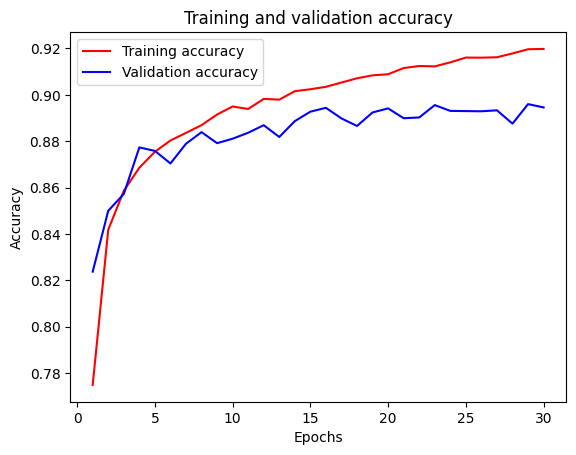

In [29]:
# show what the predictions look like for a multi-class classification problem
# pretty!

# learning curve
import matplotlib.pyplot as plt

# accuracy
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# loss
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# "r" is for "solid red line"
plt.plot(epochs, acc, 'r', label='Training accuracy')
# b is for "solid blue line"
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [30]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# see how the model did!
preds = network.predict(test_images)
preds # if you look at preds, there's actually a probability in there...

# here it is! almost a perfect prediction
# actual is left, predicted is top
# names can be found by inspecting Y
matrix = confusion_matrix(test_labels.argmax(axis=1), preds.argmax(axis=1))
matrix

  1/313 ━━━━━━━━━━━━━━━━━━━━ 15s 51ms/step

 38/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  

 89/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

131/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

170/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

205/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

236/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

273/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[831,   1,  13,  22,   4,   0, 111,   0,  18,   0],
       [  3, 971,   0,  19,   4,   0,   1,   0,   2,   0],
       [ 11,   0, 762,  13, 113,   0,  88,   0,  13,   0],
       [ 16,   6,   8, 886,  50,   0,  27,   0,   7,   0],
       [  1,   0,  57,  18, 853,   0,  68,   0,   3,   0],
       [  0,   0,   0,   1,   0, 975,   0,   9,   2,  13],
       [106,   0,  64,  32,  61,   0, 716,   0,  21,   0],
       [  0,   0,   0,   0,   0,  23,   0, 946,   1,  30],
       [  2,   0,   1,   2,   6,   2,   2,   3, 982,   0],
       [  0,   0,   0,   1,   0,   5,   1,  27,   0, 966]])

In [31]:
# with target_names, the report finally reads like clothing instead of integers
print(classification_report(test_labels.argmax(axis=1), preds.argmax(axis=1),
                            target_names=class_names))

              precision    recall  f1-score   support

 T-shirt/top       0.86      0.83      0.84      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.84      0.76      0.80      1000
       Dress       0.89      0.89      0.89      1000
        Coat       0.78      0.85      0.82      1000
      Sandal       0.97      0.97      0.97      1000
       Shirt       0.71      0.72      0.71      1000
     Sneaker       0.96      0.95      0.95      1000
         Bag       0.94      0.98      0.96      1000
  Ankle boot       0.96      0.97      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



## Hits and misses - where did the model actually go wrong?

Accuracy says *how often*. It never says *what*. With image data we can just look - so let's see the ones it nailed, and more importantly the ones it blew.

In [32]:
# the model's probabilities for every test image
probs = network.predict(test_images, verbose=0)

pred = probs.argmax(axis=1)
true = test_labels.argmax(axis=1)
conf = probs.max(axis=1)

hits = np.where(pred == true)[0]
miss = np.where(pred != true)[0]

print('hits  :', len(hits))
print('misses:', len(miss), '  out of', len(true))
print('accuracy: %.4f' % (len(hits) / len(true)))

hits  : 8888
misses: 1112   out of 10000
accuracy: 0.8888


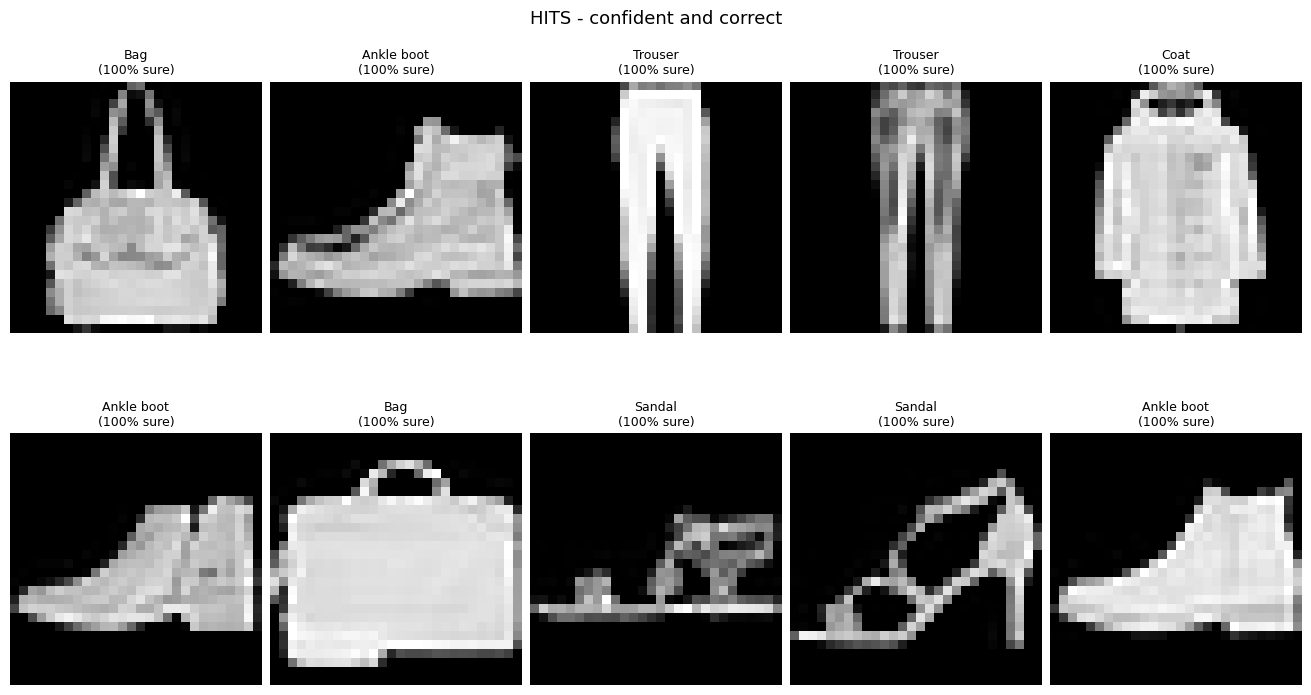

In [33]:
# HITS - ten it got right and was sure about
idx = hits[np.argsort(-conf[hits])][:10]

fig, axes = plt.subplots(2, 5, figsize=(13, 7.3), constrained_layout=True)
for i, ax in zip(idx, axes.ravel()):
    ax.imshow(test_images[i].reshape(28, 28), cmap='gray')
    ax.set_title('%s\n(%.0f%% sure)' % (class_names[pred[i]], conf[i] * 100), fontsize=9)
    ax.axis('off')
fig.suptitle('HITS - confident and correct', fontsize=13)
plt.show()

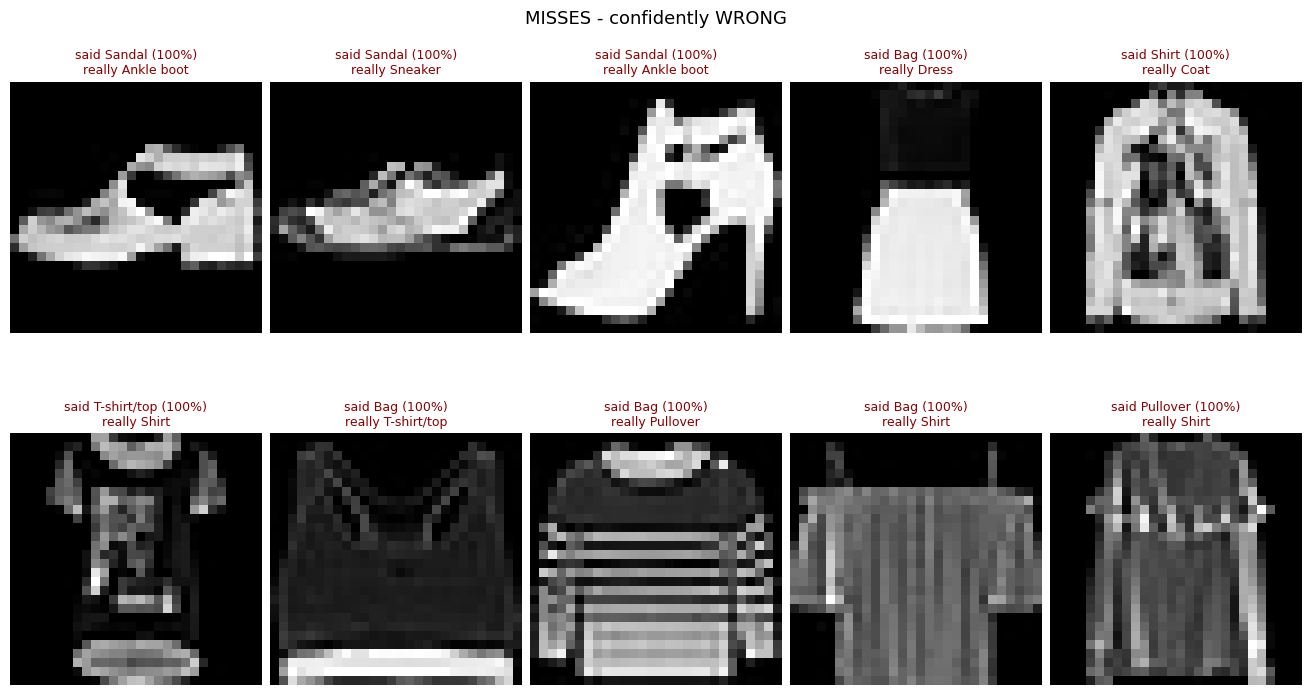

In [34]:
# MISSES - the confidently wrong ones
idx = miss[np.argsort(-conf[miss])][:10]

fig, axes = plt.subplots(2, 5, figsize=(13, 7.3), constrained_layout=True)
for i, ax in zip(idx, axes.ravel()):
    ax.imshow(test_images[i].reshape(28, 28), cmap='gray')
    ax.set_title('said %s (%.0f%%)\nreally %s' % (class_names[pred[i]], conf[i] * 100,
                                                  class_names[true[i]]),
                 fontsize=9, color='darkred')
    ax.axis('off')
fig.suptitle('MISSES - confidently WRONG', fontsize=13)
plt.show()

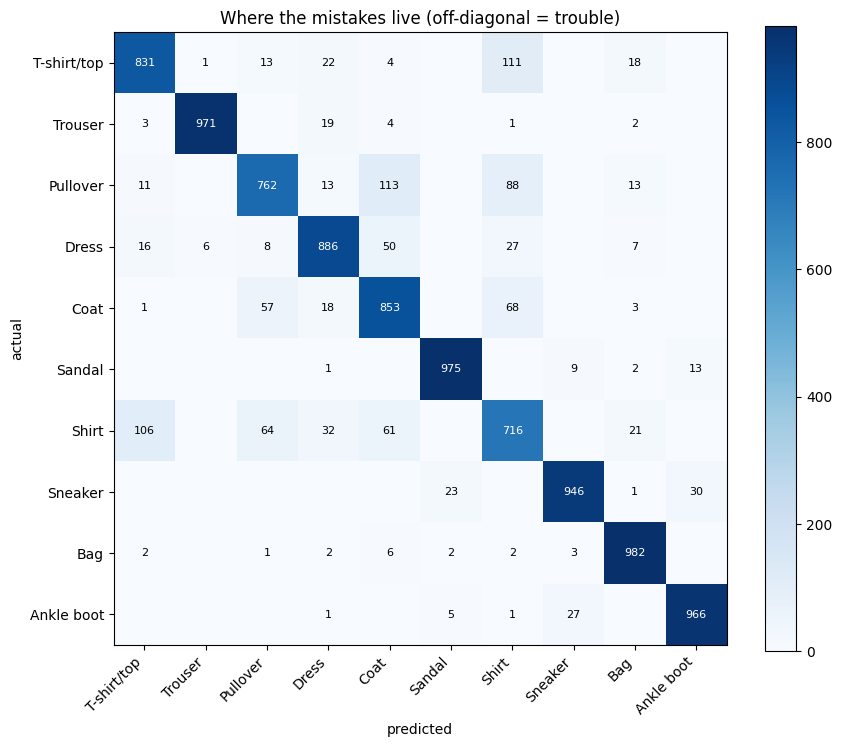

In [35]:
# WHICH pairs does it mix up? the confusion matrix, but readable
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(true, pred)

fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(10)); ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_yticks(range(10)); ax.set_yticklabels(class_names)
ax.set_xlabel('predicted'); ax.set_ylabel('actual')
ax.set_title('Where the mistakes live (off-diagonal = trouble)')
for i in range(10):
    for j in range(10):
        if cm[i, j]:
            ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=8,
                    color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.colorbar(im)
plt.tight_layout()
plt.show()

💡 Now the 89% makes sense, doesn't it? Go find the **Shirt** row. That is where this model bleeds - shirts get called T-shirts, pullovers, and coats, over and over. And look at those misses above: at 28x28 in grayscale, a shirt and a pullover really are nearly the same blob. **The model is not being dumb - the information genuinely isn't there at this resolution.**

Compare that to the digits notebook, where the errors were mostly sloppy handwriting. Same architecture, same code, same number of parameters - the *data* is what got harder. That is the whole lesson of this notebook.

**On Your Own:** print the classification report with `target_names=class_names` (already done below) and find the class with the worst recall. Then ask yourself the honest question: would a fair report to your manager lead with the 89%, or with the shirt problem?

# Try a Baseline Model for Fun
Just to show the power on DNNs, why not try a more familiar model like logistic regression? Because it's less accurate and actually takes MORE time!

In [36]:
from sklearn.linear_model import LogisticRegression
LR = LogisticRegression(max_iter=100000000)

# warning: takes a long time to fit!

# had to make a copy of the labels because it expects a 1D array,
# not like the previous to_categorical() we used.
clf = LR.fit(train_images, # X
             copy_train_labels) # y (stored in original 5, 6, 7, 9 format... original labels)

In [37]:
# evaluate confusion matrix
preds = clf.predict(test_images)

confusion_matrix(copy_test_labels, preds)

array([[806,   2,  11,  53,   4,   3, 110,   0,  11,   0],
       [  4, 956,   4,  27,   4,   0,   3,   0,   2,   0],
       [ 26,   3, 739,  10, 124,   0,  85,   1,  12,   0],
       [ 26,  17,  17, 860,  30,   0,  39,   0,  11,   0],
       [  0,   2, 113,  36, 763,   0,  80,   0,   6,   0],
       [  0,   0,   0,   1,   0, 921,   0,  50,   6,  22],
       [144,   1, 123,  40, 101,   0, 567,   0,  24,   0],
       [  0,   0,   0,   0,   0,  33,   0, 940,   0,  27],
       [  7,   1,   8,  13,   4,   5,  21,   5, 936,   0],
       [  0,   1,   0,   0,   0,  13,   1,  35,   0, 950]])

In [38]:
# evaluate train results - it does OK,
# but NN does better!

print(classification_report(copy_test_labels, preds))

              precision    recall  f1-score   support

           0       0.80      0.81      0.80      1000
           1       0.97      0.96      0.96      1000
           2       0.73      0.74      0.73      1000
           3       0.83      0.86      0.84      1000
           4       0.74      0.76      0.75      1000
           5       0.94      0.92      0.93      1000
           6       0.63      0.57      0.59      1000
           7       0.91      0.94      0.93      1000
           8       0.93      0.94      0.93      1000
           9       0.95      0.95      0.95      1000

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000



In [39]:
# interpret the output!
# what is going on with the number five?
# X is predicted, Y is actual